# AutoInsight: AI-Augmented Data Cleaning & Reporting Pipeline

This notebook cleans, validates, warehouses, visualizes, and AI-summarizes **any tabular CSV dataset.**

**How to use it:** run every cell top to bottom, then call `run_data_cleaning_pipeline(source=...)` with either a CSV URL **or** a local `.csv` file path.

## Step 1: Imports & Setup

In [1]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pydantic import create_model, ValidationError
from sqlalchemy import create_engine
from google import genai

from dotenv import load_dotenv
load_dotenv()


True

## Step 2: Dynamic Schema Validation

We **build the Pydantic model at runtime** by looking at the *actual* columns and dtypes of whatever dataset was loaded.

In [2]:
def build_dynamic_schema(df: pd.DataFrame):
    """Builds a Pydantic model on the fly, matching this dataframe's columns/types."""
    fields = {}
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            fields[col] = (float, ...)
        else:
            fields[col] = (str, ...)
    return create_model("DynamicRecord", **fields)


def validate_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Validates every row against the dynamically-built schema, dropping bad rows."""
    DynamicRecord = build_dynamic_schema(df)
    valid_rows = []
    invalid_count = 0

    for idx, row in df.iterrows():
        try:
            row_dict = {k: (v if pd.notna(v) else "") for k, v in row.to_dict().items()}
            DynamicRecord(**row_dict)
            valid_rows.append(idx)
        except ValidationError:
            invalid_count += 1

    print(f"   -> Data Validation complete: Passed {len(valid_rows)} records. "
          f"(Flagged/Dropped {invalid_count} corrupt entries)")
    return df.loc[valid_rows].copy()


## Step 3: Generic Data Loading

Just takes a URL (or local path) and reads it as a CSV, falling back to `latin1` encoding if `utf-8` fails — this covers the vast majority of messy public CSVs on GitHub.

In [3]:
def load_dataset(source: str) -> pd.DataFrame:
    """Loads a CSV from a URL OR a local file path (e.g. a CSV you've uploaded into this notebook's folder)."""
    is_url = str(source).lower().startswith(("http://", "https://"))

    if is_url:
        print(f"Fetching raw dataset from URL: {source}")
    else:
        if not os.path.isfile(source):
            raise FileNotFoundError(
                f"Could not find local CSV file: '{source}'. "
                f"Upload the file into this notebook's folder (or give the full path) and try again."
            )
        print(f"Reading raw dataset from local file: {source}")

    try:
        df = pd.read_csv(source, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(source, encoding='latin1')

    print(f"Data Ingested Successfully. Initial Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
    return df


## Step 4: Generic Cleaning Logic

- Drops junk `Unnamed: 0`-style index columns pandas sometimes creates
- Removes duplicate rows (on a column subset you provide, or on *all* columns if you don't)
- Tries to convert text-looking numbers (e.g. `"1,234"`) into real numbers
- Fills missing numeric values with the median, missing text values with `"Unknown"`

In [4]:
def clean_dataset(df: pd.DataFrame, dedup_subset: list[str] | None = None):
    df.columns = df.columns.str.upper().str.strip()

    # Drop pandas' auto-generated unnamed index columns
    df = df.loc[:, ~df.columns.str.contains('^UNNAMED')]

    initial_row_count = len(df)
    subset = dedup_subset if dedup_subset else list(df.columns)
    df = df.drop_duplicates(subset=subset, keep='first')
    duplicates_removed = initial_row_count - len(df)

    for col in df.columns:
        if df[col].dtype == 'object':
            # Try to coerce text-looking numbers into real numeric columns
            cleaned = df[col].astype(str).str.replace('"', '').str.replace(',', '').str.strip()
            converted = pd.to_numeric(cleaned, errors='coerce')
            if converted.notna().mean() > 0.8:  # mostly numeric -> treat as numeric
                df[col] = converted

        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna('Unknown').astype(str).str.replace('\xa0', '').str.strip()

    return df, duplicates_removed


## Step 5: Generic Interactive Dashboard

- the **first text column** as a label
- the **first numeric column** as the value to rank/chart
- up to 6 numeric columns for the correlation heatmap


In [5]:
import re


def _is_identifier_column(df: pd.DataFrame, col: str) -> bool:
    """Flags columns that are IDs/row-numbers rather than real metrics or labels
    (e.g. MATCH_ID, 'MATCH ID', ROW_NUMBER). Only treats an all-unique numeric
    column as an identifier if it forms a contiguous sequence (e.g. 1,2,3...) --
    a real metric like revenue can also be all-unique by coincidence in a small
    dataset, and shouldn't be excluded just for that."""
    tokens = re.split(r"[^A-Z0-9]+", str(col).upper())
    if any(t in ("ID", "NO", "NUM", "INDEX", "IDX", "CODE", "KEY") for t in tokens):
        return True

    s = df[col].dropna()
    if len(s) == 0 or s.nunique() != len(df) or s.nunique() <= 1:
        return False
    is_whole_number = pd.api.types.is_integer_dtype(s) or (
        pd.api.types.is_float_dtype(s) and (s == s.round()).all()
    )
    if not is_whole_number:
        return False
    return (s.max() - s.min() + 1) == s.nunique()  # contiguous range -> classic auto-increment ID


def _pick_value_col(df: pd.DataFrame, numeric_cols: list[str]) -> str:
    """Picks a numeric column that behaves like a real metric (excludes ID-like
    columns when possible), preferring the one with the most spread/variance."""
    candidates = [c for c in numeric_cols if not _is_identifier_column(df, c)]
    pool = candidates if candidates else numeric_cols
    return max(pool, key=lambda c: df[c].std(skipna=True) or 0)


def _pick_label_col(df: pd.DataFrame, text_cols: list[str]):
    """Picks a text column that can distinguish rows (enough unique values),
    preferring higher cardinality. Returns None if no text column is usable,
    so the caller can fall back to a synthetic row label."""
    candidates = [c for c in text_cols if df[c].nunique(dropna=True) > 1]
    if not candidates:
        return None
    return max(candidates, key=lambda c: df[c].nunique(dropna=True))


def _disambiguate_labels(labels: pd.Series) -> pd.Series:
    """Appends a counter to repeated labels (e.g. two 'Male' rows) so bars in
    the chart don't visually collide under the same y-axis category."""
    if not labels.duplicated().any():
        return labels
    seen = {}
    out = []
    for val in labels:
        seen[val] = seen.get(val, 0) + 1
        out.append(val if seen[val] == 1 else f"{val} ({seen[val]})")
    return pd.Series(out, index=labels.index)


def _build_corr_cols(df: pd.DataFrame, numeric_cols: list[str], value_col: str, max_cols: int = 6) -> list[str]:
    """Builds the column list for the correlation heatmap. Always includes
    value_col (so the caller can safely index corr_matrix[value_col] later),
    prefers real metrics over ID-like columns, and pads from all numeric
    columns if there aren't enough non-ID metrics to fill max_cols."""
    metric_cols = [c for c in numeric_cols if not _is_identifier_column(df, c)]
    pool = metric_cols if len(metric_cols) >= 2 else numeric_cols
    ordered = [value_col] + [c for c in pool if c != value_col]
    if len(ordered) < 2:
        ordered += [c for c in numeric_cols if c not in ordered]
    return ordered[:max_cols]


def build_dashboard(df: pd.DataFrame, output_dir: str):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    text_cols = df.select_dtypes(include=['object']).columns.tolist()

    if not numeric_cols:
        print("No numeric columns found -- skipping dashboard.")
        return None

    value_col = _pick_value_col(df, numeric_cols)
    label_col = _pick_label_col(df, text_cols)

    top_rows = df.sort_values(by=value_col, ascending=True).tail(5)

    if label_col is not None:
        bar_labels = _disambiguate_labels(top_rows[label_col].astype(str))
    else:
        bar_labels = pd.Series([f"Row {i}" for i in top_rows.index], index=top_rows.index)

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f'Top 5 by {value_col}', 'Metric Correlation Heatmap'),
        horizontal_spacing=0.35
    )

    bar_chart = go.Bar(
        x=top_rows[value_col],
        y=bar_labels,
        orientation='h',
        marker=dict(color=top_rows[value_col], colorscale='Viridis'),
        hovertemplate=f"<b>%{{y}}</b><br>{value_col}: %{{x:,.2f}}<extra></extra>"
    )
    fig.add_trace(bar_chart, row=1, col=1)

    y_axis_title = label_col if label_col is not None else "Row"
    fig.update_xaxes(title_text=value_col, row=1, col=1)
    fig.update_yaxes(title_text=y_axis_title, type='category', row=1, col=1)

    corr_cols = _build_corr_cols(df, numeric_cols, value_col)
    corr_matrix = df[corr_cols].corr()

    heatmap = go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns,
        y=corr_matrix.index,
        colorscale='magma',
        zmin=-1, zmax=1,
        text=np.round(corr_matrix.values, 2),
        texttemplate="%{text}",
        hoverongaps=False
    )
    fig.add_trace(heatmap, row=1, col=2)
    fig.update_xaxes(title_text="Metric", row=1, col=2)
    fig.update_yaxes(title_text="Metric", row=1, col=2)

    fig.update_layout(
        title_text="Executive Performance & Quality Dashboard",
        title_x=0.5, title_font_size=20,
        showlegend=False, height=500, width=1100,
        template="plotly_white"
    )

    interactive_report_path = os.path.join(output_dir, "interactive_report.html")
    fig.write_html(interactive_report_path)
    print(f"[Dashboard]: Interactive HTML report saved to '{interactive_report_path}'")
    fig.show()

    return corr_matrix, label_col, value_col, top_rows


## Step 6: AI Executive Summary (domain-agnostic prompt)


In [6]:
import json
import time
import hashlib


def _cache_path(output_dir: str) -> str:
    return os.path.join(output_dir, "ai_summary_cache.json")


def _load_cache(path: str) -> dict:
    if os.path.isfile(path):
        try:
            with open(path, "r") as f:
                return json.load(f)
        except Exception:
            return {}
    return {}


def _save_cache(path: str, cache: dict) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w") as f:
        json.dump(cache, f, indent=2)


def _fallback_summary(metrics_summary: str) -> str:
    """A deterministic, non-AI executive summary built directly from the
    pipeline's own metrics. Used whenever the Gemini API is unavailable
    (quota exhausted, no key, network issue, etc.) so the pipeline still
    produces a usable report instead of just an error message."""
    lines = [l.strip("- ").strip() for l in metrics_summary.strip().splitlines() if l.strip()]
    bullets = "\n".join(f"- {l}" for l in lines)
    return (
        "[Fallback summary -- AI service unavailable, generated directly from pipeline metrics]\n"
        f"{bullets}"
    )


def generate_ai_executive_summary(metrics_summary: str, output_dir: str = "automated_outputs", max_retries: int = 2) -> str:
    api_key = os.environ.get("GEMINI_API_KEY")
    if not api_key:
        return _fallback_summary(metrics_summary)

    cache_path = _cache_path(output_dir)
    cache = _load_cache(cache_path)
    cache_key = hashlib.sha256(metrics_summary.encode("utf-8")).hexdigest()

    if cache_key in cache:
        print("[AI Summary]: Using cached result for identical metrics (no API call made).")
        return cache[cache_key]

    prompt = f"""
    You are an expert Data Analyst Lead. 
    Analyze the provided data pipeline metric outputs below. Write an executive business summary consisting of exactly 5 bullet points. 
    Focus your analysis on:
    1. Overall data health and reliability.
    2. Significant anomalies, risks, or critical trends.
    3. The current data quality baseline.
    Guidelines:
    - Do not assume a specific industry. Infer the business domain directly from the metric names, table structures, and volume patterns.
    - Use precise, professional business language tailored for leadership stakeholders.
    - Keep each bullet point concise (1-2 sentences max), starting with a bold key takeaway.
    Metric outputs to analyze:
    {metrics_summary}
    """

    client = genai.Client()
    last_error = None

    for attempt in range(max_retries + 1):
        try:
            response = client.models.generate_content(
                model='gemini-3.5-flash',
                contents=prompt,
            )
            summary = response.text
            cache[cache_key] = summary
            _save_cache(cache_path, cache)
            return summary
        except Exception as e:
            last_error = e
            err_str = str(e)
            is_quota_error = "RESOURCE_EXHAUSTED" in err_str or "429" in err_str
            if is_quota_error:
                # A daily quota cap won't clear within this session, so retrying
                # just burns time -- fall back immediately instead.
                print(f"[AI Summary]: Gemini quota exhausted. Falling back to a metrics-based summary.")
                return _fallback_summary(metrics_summary)
            if attempt < max_retries:
                wait = 2 ** attempt
                print(f"[AI Summary]: Attempt {attempt + 1} failed ({e}). Retrying in {wait}s...")
                time.sleep(wait)

    print(f"[AI Summary]: All retries failed ({last_error}). Falling back to a metrics-based summary.")
    return _fallback_summary(metrics_summary)


## Step 7: Main Orchestrator

This ties everything together. You pass in:
- `source` -- any CSV URL **or** a local `.csv` file path
- `dedup_subset` -- optional list of columns that define a "duplicate row" (leave blank to use all columns)
- `table_name` -- what to call the table in the SQLite warehouse (so multiple datasets don't collide)

In [7]:
def run_data_cleaning_pipeline(source: str, dedup_subset: list[str] | None = None, table_name: str = "cleaned_data"):
    print("STARTING ENTERPRISE-GRADE DATA CLEANING & REPORTING PIPELINE")

    try:
        df = load_dataset(source)
    except Exception as e:
        print(f"Error fetching data: {e}")
        return

    print("Executing Data Preprocessing Steps...")
    df, duplicates_removed = clean_dataset(df, dedup_subset=dedup_subset)

    print("\nExecuting Schema Validation Rules...")
    df = validate_dataframe(df)

    output_dir = "automated_outputs"
    os.makedirs(output_dir, exist_ok=True)
    db_path = os.path.join(output_dir, "production_warehouse.db")
    engine = create_engine(f"sqlite:///{db_path}")
    df.to_sql(table_name, con=engine, if_exists="replace", index=False)
    print(f"\n[Storage]: Cleaned dataset written to SQL Warehouse at '{db_path}' (Table: '{table_name}')")

    print("\nGenerating Interactive Plotly Visual Summary Dashboard...")
    dashboard_result = build_dashboard(df, output_dir)

    if dashboard_result:
        corr_matrix, label_col, value_col, top_rows = dashboard_result
        top_feature = corr_matrix[value_col].drop(value_col).idxmax() if len(corr_matrix.columns) > 1 else "N/A"
        top_label = top_rows.iloc[-1][label_col] if label_col is not None else f"Row {top_rows.index[-1]}"
        metrics_context = f"""
        - Total Cleaned Rows Preserved: {len(df)}
        - Duplicate Records Dropped: {duplicates_removed}
        - Top Value ({value_col}): {top_label} ({top_rows.iloc[-1][value_col]:,.2f})
        - Top Feature Correlated with {value_col}: {top_feature}
        """
    else:
        metrics_context = f"""
        - Total Cleaned Rows Preserved: {len(df)}
        - Duplicate Records Dropped: {duplicates_removed}
        - No numeric columns available for correlation analysis.
        """

    print("\n" + "="*50)
    print("AI-GENERATED EXECUTIVE BRIEFING")
    print("="*50)
    ai_summary = generate_ai_executive_summary(metrics_context, output_dir=output_dir)
    print(ai_summary)
    print("="*50)

    return df


## Step 8: Run it on the movie dataset 

STARTING ENTERPRISE-GRADE DATA CLEANING & REPORTING PIPELINE
Fetching raw dataset from URL: https://raw.githubusercontent.com/Jcharis/Data-Cleaning-Practical-Examples/master/unclean_data.csv
Data Ingested Successfully. Initial Shape: 14 rows, 16 columns

Executing Data Preprocessing Steps...

Executing Schema Validation Rules...
   -> Data Validation complete: Passed 13 records. (Flagged/Dropped 0 corrupt entries)

[Storage]: Cleaned dataset written to SQL Warehouse at 'automated_outputs/production_warehouse.db' (Table: 'cleaned_movies')

Generating Interactive Plotly Visual Summary Dashboard...
[Dashboard]: Interactive HTML report saved to 'automated_outputs/interactive_report.html'


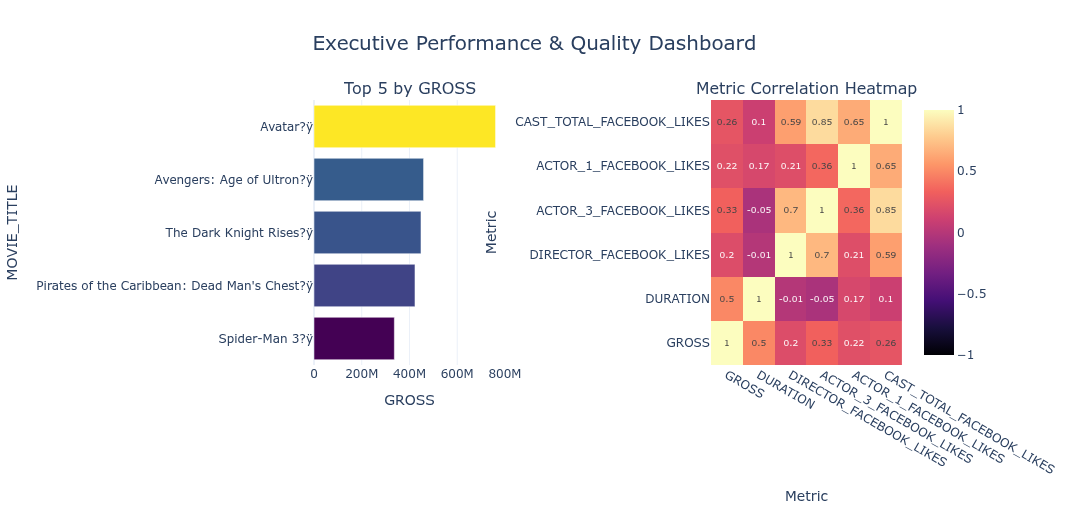


AI-GENERATED EXECUTIVE BRIEFING
[AI Summary]: Using cached result for identical metrics (no API call made).
Here is the executive business summary based on the pipeline metrics:

*   **Critical Volume Constraints in Entertainment Domain:** The pipeline processes film industry metrics (tracking box office "GROSS" and content "DURATION"), but the current dataset is critically small, yielding only 13 preserved records after filtering. This indicates either a highly restricted test sample or a severe upstream data ingestion issue that is limiting our analytics pipeline.
*   **Establishment of Data Quality Baseline & Encoding Issues:** While deduplication successfully identified and removed one redundant record, the data quality baseline is compromised by character-encoding corruption (as seen in the malformed string "Avatar?ÿ"). Standardizing text encoding (e.g., UTF-8) and validating ingestion pipelines are required to ensure data integrity. 
*   **Directional Trend Linking Runtime to Re

,MOVIE_TITLE,NUM_CRITIC_FOR_REVIEWS,DURATION,DIRECTOR_FACEBOOK_LIKES,ACTOR_3_FACEBOOK_LIKES,ACTOR_1_FACEBOOK_LIKES,GROSS,NUM_VOTED_USERS,CAST_TOTAL_FACEBOOK_LIKES,FACENUMBER_IN_POSTER,NUM_USER_FOR_REVIEWS,BUDGET,TITLE_YEAR,ACTOR_2_FACEBOOK_LIKES,IMDB_SCORE,TITLE_YEAR.1
0,Avatar?ÿ,723,178.0,10.0,855,1000,760505847,886204.0,4834.0,1.5,3054,237000000,2009,936.0,7.9,2009.0
1,Pirates of the Caribbean: At World's End?ÿ,302,152.0,563.0,1000,40000,309404152,471220.0,48350.0,1.5,1238,300000000,2007,5000.0,7.1,2008.5
2,Spectre?ÿ,602,148.0,20.0,161,11000,200074175,275868.0,11700.0,1.0,994,245000000,2015,393.0,6.8,2015.0
3,The Dark Knight Rises?ÿ,813,152.0,22000.0,23000,27000,448130642,1144337.0,106759.0,1.5,2701,250000000,2012,23000.0,8.5,2008.5
4,John Carter?ÿ,462,132.0,475.0,530,640,73058679,212204.0,1873.0,1.0,738,263700000,2012,632.0,6.6,2008.5
5,Spider-Man 3?ÿ,392,156.0,23.0,4000,24000,336530303,383056.0,46055.0,1.5,1902,258000000,2007,11000.0,6.2,2007.0
6,Tangled?ÿ,324,152.0,15.0,284,799,200807262,294810.0,46055.0,1.0,387,260000000,2010,553.0,7.8,2008.5
7,Avengers: Age of Ultron?ÿ,635,141.0,10.0,19000,26000,458991599,462669.0,92000.0,4.0,1117,250000000,2015,21000.0,7.5,2008.5
9,Harry Potter and the Half-Blood Prince?ÿ,375,153.0,282.0,10000,25000,301956980,321795.0,58753.0,3.0,973,250000000,2009,11000.0,7.5,2008.5
10,Batman v Superman: Dawn of Justice?ÿ,673,183.0,282.0,2000,15000,330249062,356920.0,24450.0,1.5,3018,250000000,2016,5000.0,6.9,2016.0


In [8]:
run_data_cleaning_pipeline(
    source="https://raw.githubusercontent.com/Jcharis/Data-Cleaning-Practical-Examples/master/unclean_data.csv",
    dedup_subset=["MOVIE_TITLE", "TITLE_YEAR"],
    table_name="cleaned_movies"
)


## Step 9: run it on a different dataset

`tips.csv` is a well-known restaurant-tips dataset with totally different columns (`total_bill`, `tip`, `sex`, `day`...)

STARTING ENTERPRISE-GRADE DATA CLEANING & REPORTING PIPELINE
Fetching raw dataset from URL: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv
Data Ingested Successfully. Initial Shape: 244 rows, 7 columns

Executing Data Preprocessing Steps...

Executing Schema Validation Rules...
   -> Data Validation complete: Passed 243 records. (Flagged/Dropped 0 corrupt entries)

[Storage]: Cleaned dataset written to SQL Warehouse at 'automated_outputs/production_warehouse.db' (Table: 'cleaned_tips')

Generating Interactive Plotly Visual Summary Dashboard...
[Dashboard]: Interactive HTML report saved to 'automated_outputs/interactive_report.html'


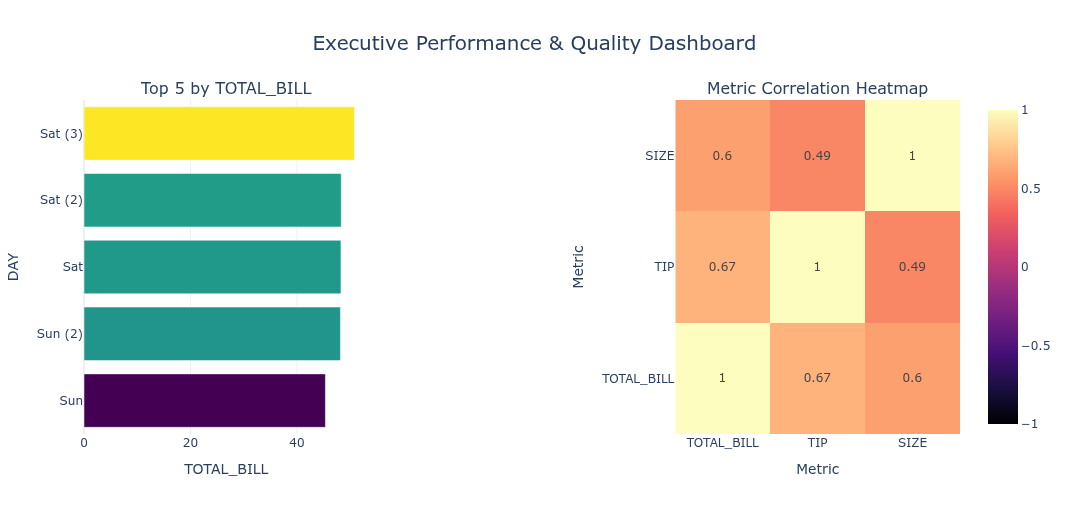


AI-GENERATED EXECUTIVE BRIEFING
[AI Summary]: Using cached result for identical metrics (no API call made).
Here is the executive business summary of the pipeline metrics:

*   **High-Integrity Data Health in Hospitality Transactions:** The pipeline successfully processed transactional data inferred to be from the hospitality or restaurant industry. Overall data health is exceptional, with a negligible duplication rate (only 1 record dropped); this leaves a highly pristine baseline of 243 fully cleaned and preserved rows ready for downstream analytics.
*   **Saturday Revenue Peaks and Strong Gratuity Correlations:** Key behavioral trends indicate that Saturday is the premium revenue-generating day, yielding a peak transaction value of 50.81. Furthermore, "TIP" emerged as the feature most strongly correlated with "TOTAL_BILL," confirming that gratuities scale predictably with customer spend—a vital insight for staff scheduling and performance incentive modeling. 
*   **Established Qual

,TOTAL_BILL,TIP,SEX,SMOKER,DAY,TIME,SIZE
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [9]:
run_data_cleaning_pipeline(
    source="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv",
    table_name="cleaned_tips"
)


## Step 9b: Run it on a local CSV file 

STARTING ENTERPRISE-GRADE DATA CLEANING & REPORTING PIPELINE
Reading raw dataset from local file: ball_by_ball_ipl.csv
Data Ingested Successfully. Initial Shape: 239693 rows, 35 columns

Executing Data Preprocessing Steps...

Executing Schema Validation Rules...
   -> Data Validation complete: Passed 239693 records. (Flagged/Dropped 0 corrupt entries)

[Storage]: Cleaned dataset written to SQL Warehouse at 'automated_outputs/production_warehouse.db' (Table: 'cleaned_local_upload')

Generating Interactive Plotly Visual Summary Dashboard...
[Dashboard]: Interactive HTML report saved to 'automated_outputs/interactive_report.html'


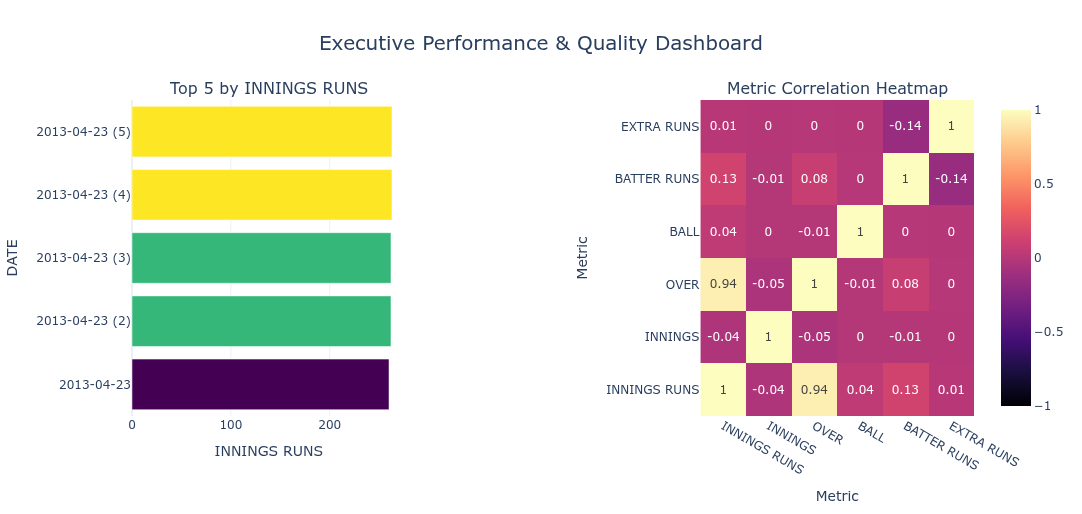


AI-GENERATED EXECUTIVE BRIEFING
[AI Summary]: Using cached result for identical metrics (no API call made).
Here is the executive business summary based on the pipeline metrics:

*   **Exceptional Data Health and Pipeline Integrity:** The ingestion pipeline successfully processed and preserved a robust dataset of 239,693 clean records with zero duplicate records dropped. This indicates highly reliable upstream data collection and an pristine quality baseline, ensuring that downstream analytics and reporting are free from deduplication noise.
*   **Domain Inference & Historical Performance Benchmarks:** The metrics point directly to the **sports analytics domain (specifically cricket)**, capturing match-level progression data. The dataset highlights a significant historical benchmark on April 23, 2013, where "INNINGS RUNS" peaked at an extraordinary 263.00 (a famous record-setting event in cricket history), which serves as a critical high-performance outlier for model training.
*   **K

,MATCH ID,DATE,VENUE,BAT FIRST,BAT SECOND,INNINGS,OVER,BALL,BATTER,NON STRIKER,...,WINNER,CHASED SUCCESSFULLY,TOTAL BATTER RUNS,TOTAL NON STRIKER RUNS,BATTER BALLS FACED,NON STRIKER BALLS FACED,PLAYER OUT RUNS,PLAYER OUT BALLS FACED,BOWLER RUNS CONCEDED,VALID BALL
0,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,1,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,4,0,1,0,12.0,12.0,4,1
1,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,2,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,4,0,2,0,12.0,12.0,0,1
2,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,3,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,4,0,3,0,12.0,12.0,0,1
3,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,4,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,4,0,4,0,12.0,12.0,0,1
4,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,5,RD Gaikwad,DP Conway,...,Chennai Super Kings,0,5,0,5,0,12.0,12.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239688,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,1,YK Pathan,KS Williamson,...,Sunrisers Hyderabad,1,16,31,9,29,12.0,12.0,2,1
239689,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,2,YK Pathan,KS Williamson,...,Sunrisers Hyderabad,1,22,31,10,29,12.0,12.0,6,1
239690,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,3,YK Pathan,KS Williamson,...,Sunrisers Hyderabad,1,26,31,11,29,12.0,12.0,4,1
239691,1136596,2018-05-05,Rajiv Gandhi International Stadium,Delhi Daredevils,Sunrisers Hyderabad,2,20,4,YK Pathan,KS Williamson,...,Sunrisers Hyderabad,1,27,31,12,29,12.0,12.0,1,1


In [10]:
run_data_cleaning_pipeline(
    source="ball_by_ball_ipl.csv",  
    table_name="cleaned_local_upload"
)


STARTING ENTERPRISE-GRADE DATA CLEANING & REPORTING PIPELINE
Reading raw dataset from local file: MSFT.csv
Data Ingested Successfully. Initial Shape: 4178 rows, 7 columns

Executing Data Preprocessing Steps...

Executing Schema Validation Rules...
   -> Data Validation complete: Passed 4178 records. (Flagged/Dropped 0 corrupt entries)

[Storage]: Cleaned dataset written to SQL Warehouse at 'automated_outputs/production_warehouse.db' (Table: 'cleaned_local_upload')

Generating Interactive Plotly Visual Summary Dashboard...
[Dashboard]: Interactive HTML report saved to 'automated_outputs/interactive_report.html'


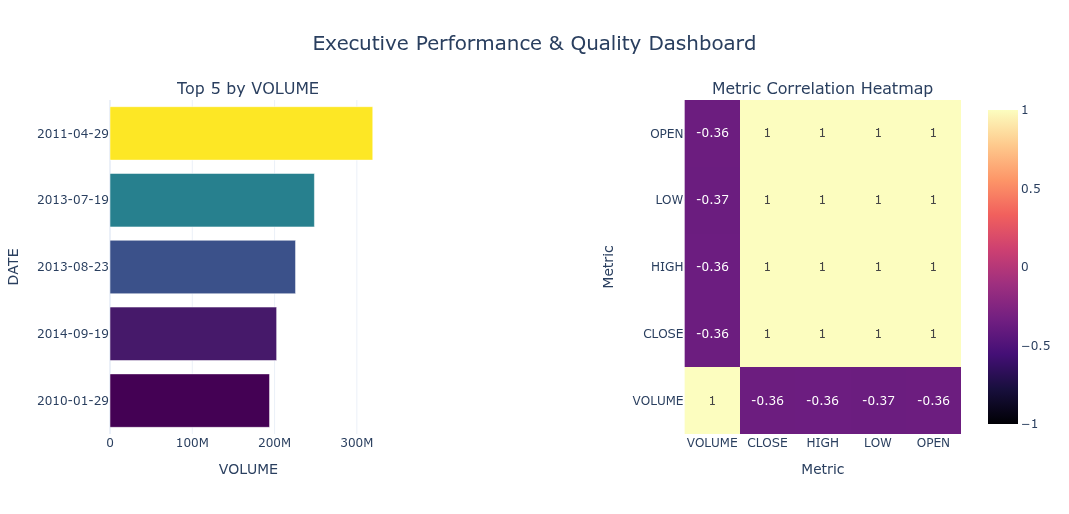


AI-GENERATED EXECUTIVE BRIEFING
[AI Summary]: Using cached result for identical metrics (no API call made).
* **High-fidelity dataset integrity.** The data pipeline successfully preserved 4,178 cleaned records with zero duplicate entries dropped, establishing a highly reliable and clean baseline for downstream modeling.
* **Financial market domain alignment.** The underlying metrics—specifically daily trading "VOLUME" and its strong correlation with the asset's "HIGH" price—indicate this dataset tracks historical financial market or equity trading behavior.
* **Significant historical volume anomaly.** A massive trading volume spike of 319,317,900 units occurred on April 29, 2011, representing a critical historical anomaly or market event that requires targeted risk assessment. 
* **Key predictive feature correlation.** The strong correlation between "VOLUME" and the daily "HIGH" price suggests that market liquidity and trading activity are heavily driven by upward price momentum and v

,DATE,CLOSE,HIGH,LOW,OPEN,VOLUME,SYMBOL
0,2010-01-04,23.027512,23.139115,22.759663,22.781984,38409100,MSFT
1,2010-01-05,23.034945,23.139109,22.796857,22.953103,49749600,MSFT
2,2010-01-06,22.893576,23.124222,22.707570,22.975417,58182400,MSFT
3,2010-01-07,22.655499,22.841504,22.462052,22.789421,50559700,MSFT
4,2010-01-08,22.811747,22.975431,22.499257,22.529018,51197400,MSFT
...,...,...,...,...,...,...,...
4173,2026-08-07,499.989990,505.179993,498.730011,499.209991,28818000,MSFT
4174,2026-08-10,506.059998,513.729980,502.269989,503.440002,31206100,MSFT
4175,2026-08-11,503.809998,505.329987,499.549988,504.329987,23049800,MSFT
4176,2026-08-12,492.429993,501.500000,491.519989,499.989990,29001500,MSFT


In [11]:
run_data_cleaning_pipeline(
    source="MSFT.csv",  
    table_name="cleaned_local_upload"
)


## Step 10: Inspect everything sitting in the SQL warehouse

In [12]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("automated_outputs/production_warehouse.db")

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
table_names = tables['name'].tolist()
print("Tables currently in warehouse:", table_names)

for table_name in table_names:
    print(f"\n--- {table_name} ---")
    df_from_db = pd.read_sql_query(f'SELECT * FROM "{table_name}"', conn)
    display(df_from_db.head())

conn.close()


Tables currently in warehouse: ['cleaned_movies', 'cleaned_tips', 'cleaned_local_upload']

--- cleaned_movies ---


,MOVIE_TITLE,NUM_CRITIC_FOR_REVIEWS,DURATION,DIRECTOR_FACEBOOK_LIKES,ACTOR_3_FACEBOOK_LIKES,ACTOR_1_FACEBOOK_LIKES,GROSS,NUM_VOTED_USERS,CAST_TOTAL_FACEBOOK_LIKES,FACENUMBER_IN_POSTER,NUM_USER_FOR_REVIEWS,BUDGET,TITLE_YEAR,ACTOR_2_FACEBOOK_LIKES,IMDB_SCORE,TITLE_YEAR.1
0,Avatar?ÿ,723,178.0,10.0,855,1000,760505847,886204.0,4834.0,1.5,3054,237000000,2009,936.0,7.9,2009.0
1,Pirates of the Caribbean: At World's End?ÿ,302,152.0,563.0,1000,40000,309404152,471220.0,48350.0,1.5,1238,300000000,2007,5000.0,7.1,2008.5
2,Spectre?ÿ,602,148.0,20.0,161,11000,200074175,275868.0,11700.0,1.0,994,245000000,2015,393.0,6.8,2015.0
3,The Dark Knight Rises?ÿ,813,152.0,22000.0,23000,27000,448130642,1144337.0,106759.0,1.5,2701,250000000,2012,23000.0,8.5,2008.5
4,John Carter?ÿ,462,132.0,475.0,530,640,73058679,212204.0,1873.0,1.0,738,263700000,2012,632.0,6.6,2008.5



--- cleaned_tips ---


,TOTAL_BILL,TIP,SEX,SMOKER,DAY,TIME,SIZE
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



--- cleaned_local_upload ---


,DATE,CLOSE,HIGH,LOW,OPEN,VOLUME,SYMBOL
0,2010-01-04,23.027512,23.139115,22.759663,22.781984,38409100,MSFT
1,2010-01-05,23.034945,23.139109,22.796857,22.953103,49749600,MSFT
2,2010-01-06,22.893576,23.124222,22.707570,22.975417,58182400,MSFT
3,2010-01-07,22.655499,22.841504,22.462052,22.789421,50559700,MSFT
4,2010-01-08,22.811747,22.975431,22.499257,22.529018,51197400,MSFT
